<a href="https://colab.research.google.com/github/DymaStar/Analysis_Cafe_Sales-/blob/main/EDA_cafe_sales_pr_DimaStar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis Cafe Sales

Cafe Sales - Dirty Data for Cleaning Training

About Dataset
Dirty Cafe Sales Dataset
Overview
The Dirty Cafe Sales dataset contains 10,000 rows of synthetic data representing sales transactions in a cafe. This dataset is intentionally "dirty," with missing values, inconsistent data, and errors introduced to provide a realistic scenario for data cleaning and exploratory data analysis (EDA). It can be used to practice cleaning techniques, data wrangling, and feature engineering.

File Information
File Name: dirty_cafe_sales.csv
Number of Rows: 10,000
Number of Columns: 8

## Columns Description

- `Transaction ID` — A unique identifier for each transaction. Always present and unique.
- `Item` — The name of the item purchased. May contain missing or invalid values (e.g., "ERROR").
- `Quantity` — The quantity of the item purchased. May contain missing or invalid values. `1`, `3`, `UNKNOWN`
- `Price Per Unit` — The price of a single unit of the item. May contain missing or invalid values. `2.00`, `4.00`
- `Total Spent` — The total amount spent on the transaction. Calculated as Quantity × Price Per Unit. `8.00`, `12.00`
- `Payment Method` — The method of payment used. May contain missing or invalid values (e.g., None, "UNKNOWN"). `Cash`, `Credit Card`
- `Location` — The location where the transaction occurred. May contain missing or invalid values. `In-store`, `Takeaway`
- `Transaction Date` — The date of the transaction. May contain missing or incorrect values. `2023-01-01`

## Columns Description

| Column Name | Description | Example Values |
|---|---|---|
| `Transaction ID` | A unique identifier for each transaction. Always present and unique. | `TXN_1234567` |
| `Item` | The name of the item purchased. May contain missing or invalid values (e.g., "ERROR"). | `Coffee`, `Sandwich` |
| `Quantity` | The quantity of the item purchased. May contain missing or invalid values. | `1`, `3`, `UNKNOWN` |
| `Price Per Unit` | The price of a single unit of the item. May contain missing or invalid values. | `2.00`, `4.00` |
| `Total Spent` | The total amount spent on the transaction. Calculated as Quantity × Price Per Unit. | `8.00`, `12.00` |
| `Payment Method` | The method of payment used. May contain missing or invalid values (e.g., None, "UNKNOWN"). | `Cash`, `Credit Card` |
| `Location` | The location where the transaction occurred. May contain missing or invalid values. | `In-store`, `Takeaway` |
| `Transaction Date` | The date of the transaction. May contain missing or incorrect values. | `2023-01-01` |

!pip install numpy pandas matplotlib

In [215]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##Завантаження датасету

In [216]:
url = 'https://raw.githubusercontent.com/DymaStar/Analysis_Cafe_Sales-/refs/heads/main/data/dirty_cafe_sales.csv'
df_origin = pd.read_csv(url)
df_origin.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [217]:
df = df_origin.copy()


##Primary diagnosis —
 Первинна діагностика

In [218]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [220]:
# Виведення типів даних колонок
print("type:\n")
df.dtypes

type:



,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object



##Problem:

Numeric columns (Quantity, Price Per Unit, Total Spent)

Date columns (Transaction Date)

In [221]:
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
# missing_report
#missing_pct
# Фільтрація: вивести лише колонки, де є пропуски
missing_report[missing_report['count'] > 0]

Missing values:



,count,%
Item,333,3.3
Quantity,138,1.4
Price Per Unit,179,1.8
Total Spent,173,1.7
Payment Method,2579,25.8
Location,3265,32.6
Transaction Date,159,1.6


In [222]:
print("Unique values:\n")

print("--- Item ---\n")
# print(df['Item'].value_counts(dropna=False))
display(df['Item'].value_counts(dropna=False))

print("\n--- Payment Method ---\n")
display(df['Payment Method'].value_counts(dropna=False))

print("\n--- Location ---\n")
display(df['Location'].value_counts(dropna=False))

Unique values:

--- Item ---



,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344



--- Payment Method ---



,count
Payment Method,
NaN,2579
Digital Wallet,2291
Credit Card,2273
Cash,2258
ERROR,306
UNKNOWN,293



--- Location ---



,count
Location,
NaN,3265
Takeaway,3022
In-store,3017
ERROR,358
UNKNOWN,338


In [223]:
print("Find lines with 'ERROR' or 'UNKNOWN'\n")
display(df.isin(['ERROR', 'UNKNOWN']).any())

display(df.isin(['ERROR', 'UNKNOWN']).sum()) #Замість True/False записати кількість 'ERROR' та 'UNKNOWN' у кожному стовпчику

mask_error = df.isin(['ERROR', 'UNKNOWN']).any(axis=1)
print(f"Lines with 'ERROR' or 'UNKNOWN': {mask_error.sum()}")

Find lines with 'ERROR' or 'UNKNOWN'



,0
Transaction ID,False
Item,True
Quantity,True
Price Per Unit,True
Total Spent,True
Payment Method,True
Location,True
Transaction Date,True


,0
Transaction ID,0
Item,636
Quantity,341
Price Per Unit,354
Total Spent,329
Payment Method,599
Location,696
Transaction Date,301


Lines with 'ERROR' or 'UNKNOWN': 2845


##**Data cleaning**

Якщо не зроблена копія датасету — тут НЕОБХІДНО створити!!!!

df_origin — origin dataset

df — copy origin dataset

## 2.1 Очищення та стандартизація назв колонок (Snake Case)

Перед аналізом важливо привести назви колонок до єдиного формату **snake_case** — це усуває пробіли, великі літери та непослідовності, що спрощує подальший доступ до даних.

#### А. Перетворення назв колонок у нижній регістр із розбивкою на слова

`str.lower()` робить усі літери малими, а `str.split()` розбиває рядок по пробілах і повертає список слів.

`````python
df.columns.str.lower().str.split()
```

#### Б. Найнадійніший спосіб створення snake_case (через `split` та `join`)

Спочатку `.lower().split()` прибирає зайві пробіли всередині рядка та створює список слів, а потім `"_".join()` з'єднує ці слова через нижнє підкреслення.

````python
"_".join("   Transaction   Date   ".lower().split())
# Результат: 'transaction_date'
\```

#### В. Метод `strip` + `replace` (менш надійний спосіб)

`.strip()` прибирає пробіли лише на початку та в кінці рядка, а `.replace(" ", "_")` замінює кожен пробіл на підкреслення. ⚠️ **Увага:** якщо між словами два пробіли — отримаєте подвійне підкреслення `__`.

```python
"   Transaction Date   ".strip().lower().replace(" ", "_")
# Результат: 'transaction_date'
```
```

> **Примітка:** перед вставкою видали зворотні слеші `\` перед закриваючими ` ``` ` — вони додані лише щоб показати текст тут без конфлікту форматування.

## 2.2 Перейменування колонок датасету

Після того як у блоці **2.1** ми розглянули методи перетворення рядків, тут застосовуємо їх на практиці до реального датасету.

**Алгоритм очищення:**

1. `.str.strip()` — прибирає випадкові пробіли на початку та в кінці назв колонок
2. `df.rename(columns={...})` — явно перейменовує кожну колонку у формат **snake_case**

> 💡 **Чому явне перейменування надійніше автоматичного?**  
> Масовий `.str.replace(" ", "_")` не контролює результат — він просто замінює пробіли.  
> Явний словник `rename` гарантує точні назви та одразу документує відповідність між старими і новими іменами.

In [224]:
print("Rename columns:\n")

# Очищення назв від зайвих пробілів на початку та в кінці
df.columns = df.columns.str.strip()

# Масове перейменування для приведення до стандарту snake_case
# Примітка: закоментований рядок нижче показує альтернативний, але менш надійний спосіб
# df.columns.str.lower().str.replace(" ", "_")

df = df.rename(columns={
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_unit',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'
})

# Вивід фінального списку колонок для перевірки
print(list(df.columns))


Rename columns:

['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


In [225]:
# 1. Перетворення назв усіх колонок у список слів у нижньому регістрі
# str.lower() робить літери малими, а str.split() розбиває рядок по пробілах


df.columns.str.lower().str.split()


# 2. Найнадійніший спосіб створення snake_case (через split та join)
# Спочатку .lower().split() прибирає зайві пробіли всередині та створює список слів,
# а потім "_".join() з'єднує ці слова за допомогою нижнього підкреслення


"_".join("  Transaction   Date  ".lower().split())

# Результат: 'transaction_date'


# 3. Використання strip та replace (менш надійний спосіб)
# .strip() прибирає пробіли лише на початку та в кінці,
# .replace(" ", "_") замінює пробіл на підкреслення.
# Якщо між словами два пробіли — отримаєте подвійне підкреслення (__)
" Transaction Date ".strip().lower().replace(" ", "_")
# Результат: 'transaction_date'


# 4. Демонстрація того ж методу strip/replace для перевірки
" Transaction Date ".strip().lower().replace(" ", "_")
# Результат: 'transaction_date'

'transaction_date'

In [226]:
# Заміна текстових маркерів помилок на NaN (Not a Number)
# Ми передаємо список усіх можливих варіацій 'ERROR' та 'UNKNOWN'
# np.nan дозволяє Pandas ігнорувати ці клітинки при математичних розрахунках
df.replace(['ERROR', 'UNKNOWN', 'error', 'unknown', ''], np.nan, inplace=True)

# Перегляд перших 5 рядків датафрейму для візуальної перевірки змін
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [227]:
# 1. Конвертація числових колонок у циклі
# Ми проходимо по списку назв і перетворюємо їх на числа (float/int)
for col in ['quantity', 'price_per_unit', 'total_spent']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Конвертація колонки з датами
# pd.to_datetime перетворює текст на спеціальний формат об'єкта дати
# errors='coerce' так само перетворить помилкові дати на NaT (Not a Time)
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

# Перегляд вмісту стовпця 'transaction_date' після конвертації
df['transaction_date']

# 3. Перевірка фінальних типів даних
# Тепер transaction_date має бути datetime64, а інші — float64
df.dtypes


,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]


### Учбове дослідження

## 2.3 Приведення колонок до правильних типів даних

Після перейменування переконуємося, що кожна колонка має **коректний тип** — це критично для подальших обчислень та фільтрації.

#### А. Експеримент у "пісочниці" — `pd.to_numeric`

Перед застосуванням до реального датасету перевіряємо поведінку функції на тестовому датафреймі зі змішаними значеннями: числа, порожній рядок `''`, пропуск `NaN` та текстовий сміттєвий рядок `"q"`.

```python
new_df = pd.DataFrame({"quantity": [0, 3, 5, '', np.nan, "q"]})
pd.to_numeric(new_df['quantity'], errors='coerce')
```

Параметр `errors='coerce'` — ключовий: замість помилки він перетворює будь-яке нечислове значення на `NaN`, що дозволяє безпечно очистити колонку.

#### Б. Перетворення дат — `pd.to_datetime`

Стовпець `transaction_date` зберігається як текст типу `object` — Python не розуміє його як дату. Конвертуємо у справжній тип `datetime64`:

```python
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
```

Після цього стають доступні операції: сортування за датою, виділення місяця/року, різниця між датами тощо.

> ⚠️ **`errors='coerce'` тут також обов'язковий** — некоректні або порожні дати перетворяться на `NaT` *(Not a Time)* замість того, щоб зламати виконання коду.

In [228]:
# 1. Експеримент на тестовому датафреймі
# Створюємо "пісочницю" зі змішаними типами: числа, порожній рядок, пропуск та текст "q"
new_df = pd.DataFrame({"quantity": [0, 3, 5, '', np.nan, "q"]})

# Закоментовані перевірки (використовувалися для діагностики типу object)
# display(new_df)
# new_df.info()

# Демонстрація очищення: pd.to_numeric з errors='coerce' примусово перетворить
# текстові аномалії ('', 'q') на NaN, залишаючи лише чисті числа
pd.to_numeric(new_df['quantity'], errors='coerce')


# 2. Обробка дат у основному датафреймі
# Перетворюємо стовпець transaction_date на справжній тип datetime
# errors='coerce' гарантує, що некоректні дати стануть NaT (Not a Time), а не зламають код
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

## 2.4 Витяг часових ознак з `transaction_date`

Після конвертації у тип `datetime64` колонка дати стає "розумною" — з неї можна витягти окремі складові для подальшого групування та візуалізації.

Аксесор `.dt` відкриває доступ до часових властивостей колонки. Без нього Pandas не знає, що ти хочеш саме рік чи місяць.

> 💡 **Чому `Int64` з великої літери, а не `int64`?**  
> Звичайний `int64` не підтримує `NaN` — якщо хоч одна дата відсутня (`NaT`), конвертація впаде з помилкою. Nullable-тип `Int64` (велика `I`) зберігає пропуски коректно.

> 💡 **Чому `strftime('%B')` замість `.month_name()`?**  
> `.month_name()` залежить від локалі операційної системи і може повернути назву не англійською. `strftime('%B')` завжди стабільний.

In [229]:
# Витяг часових ознак з колонки transaction_date
# .dt — аксесор, що відкриває доступ до часових властивостей datetime-колонки

df['year']  = df['transaction_date'].dt.year.astype('Int64')   # рік: 2023
df['month'] = df['transaction_date'].dt.month.astype('Int8')   # номер місяця: 1–12

# strftime('%B') — повна назва місяця англійською (January, February...)
# надійніший за .month_name(), який залежить від локалі системи
# df['month_name'] = df['transaction_date'].dt.month_name()
df['month_name'] = df['transaction_date'].dt.strftime('%B')

df['weekday'] = df['transaction_date'].dt.day_name()  # назва дня: Monday, Tuesday...

# isocalendar() повертає дату за стандартом ISO 8601
# .week — номер тижня в році (1–53), зручно для тижневих трендів
df['week'] = df['transaction_date'].dt.isocalendar().week.astype('Int8')

# display(df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'week']].dtypes)
df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'week']].head()

,transaction_date,year,month,month_name,weekday,week
0,2023-09-08,2023,9,September,Friday,36
1,2023-05-16,2023,5,May,Tuesday,20
2,2023-07-19,2023,7,July,Wednesday,29
3,2023-04-27,2023,4,April,Thursday,17
4,2023-06-11,2023,6,June,Sunday,23


## 2.5 Відновлення `total_spent` з наявних даних

Частина значень `total_spent` відсутня через помилки у вихідному датасеті.  
Але якщо відомі `quantity` та `price_per_unit` — значення можна **відновити математично** без втрати рядка.

Використовуємо **булеву маску**: відбираємо лише ті рядки де одночасно виконуються три умови, і заповнюємо тільки їх — решта даних не змінюється.

In [230]:
# Маска: рядки де total_spent відсутній, але є і quantity, і price_per_unit
mask_recoverable = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

# Відновлення: записуємо добуток тільки у відфільтровані рядки
df.loc[mask_recoverable, 'total_spent'] = (
    df.loc[mask_recoverable, 'quantity'] *
    df.loc[mask_recoverable, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable.sum()} string (quantity * price) ")

Restoring total_spent: 462 string (quantity * price) 


## 2.6 Відновлення `price_per_unit` через медіану по товару

Якщо ціна відсутня, але відомий товар (`item`) — підставляємо **медіанну ціну** для цього товару, розраховану по наявних даних.

Медіана стійкіша за середнє: вона не зміщується через викиди (наприклад, якщо одна транзакція містить аномально велику ціну).

**Алгоритм:**
1. Рахуємо медіанну ціну для кожного товару по чистих рядках
2. Зберігаємо результат у словник `price_map`
3. Підставляємо значення зі словника туди де ціна відсутня

In [231]:
# Крок 1: будуємо словник {назва товару: медіанна ціна}
# dropna прибирає рядки де item або price_per_unit відсутні — щоб не спотворити медіану
price_map = (
    df.dropna(subset=['item', 'price_per_unit'])
    .groupby('item')['price_per_unit']
    .median()
    .to_dict()
)

# Крок 2: маска — рядки де ціна відсутня, але товар відомий
mask_price = df['price_per_unit'].isna() & df['item'].notna()

# Крок 3: підставляємо медіанну ціну зі словника через .map()
df.loc[mask_price, 'price_per_unit'] = df.loc[mask_price, 'item'].map(price_map)

print(f"Restoring price_per_unit: {mask_price.sum()} string (median per item) ")

Restoring price_per_unit: 479 string (median per item) 


In [232]:
# Другий прохід відновлення total_spent —
# тепер є нові значення price_per_unit з попереднього кроку,
# тому деякі рядки можна відновити повторно
mask_recoverable2 = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable2, 'total_spent'] = (
    df.loc[mask_recoverable2, 'quantity'] *
    df.loc[mask_recoverable2, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable2.sum()} string (new price - median item) ")

Restoring total_spent: 17 string (new price - median item) 


## 2.7 Заповнення залишкових пропусків

Після математичного відновлення залишаються категоріальні колонки з пропусками.  
Для кожної обираємо стратегію окремо:

| Колонка | Стратегія | Причина |
|---|---|---|
| `item` | мода (найчастіше значення) | є домінуючий товар у продажах |
| `payment_method` | `'Unknown'` | немає підстав вигадувати метод оплати |
| `location` | `'Unknown'` | місце невідоме — краще зберегти чесно |

In [233]:
# item -> заповнюємо модою (найпопулярніший товар у датасеті)
# mode() повертає Series, [0] бере перший елемент
mode_item = df['item'].mode()[0]

# df['item'].fillna(mode_item, inplace=True)  # old version
df.fillna({'item': mode_item}, inplace=True)

In [234]:
# payment_method та location -> заповнюємо рядком 'Unknown'
# це чесніше ніж вигадувати значення — аналітик бачить що дані були відсутні
df.fillna(
    {
        'payment_method': 'Unknown',
        'location':       'Unknown'
    },
    inplace=True
)

## 2.8 Видалення невідновлюваних рядків та дублікатів

Деякі рядки неможливо відновити жодним способом — якщо відсутні дата транзакції або кількість, такий рядок непридатний для аналізу.

> ⚠️ **Важливо:** `dropna` видаляє рядки **назавжди**. Саме тому на початку ми зберегли незайманий оригінал у `df_origin` — завжди є змога повернутись.

In [235]:
# Видаляємо рядки де відсутня дата або кількість
before = len(df)

df.dropna(subset=['transaction_date', 'quantity'], inplace=True)

after = len(df)
print(f"Deleted {before - after} rows")

Deleted 914 rows


In [236]:
# Видалення повних дублікатів
df.duplicated().sum()  # 0
df.drop_duplicates(inplace=True)

## 2.9 Фінальна перевірка якості даних

Перед тим як переходити до аналізу — перевіряємо що очищення не залишило аномалій.

**Що перевіряємо:**
- `&` (І) — рядки де **обидві** колонки одночасно порожні → має бути `0`
- `|` (АБО) — рядки де **хоча б одна** порожня → показує скільки залишилось пропусків
- від'ємні значення у числових колонках → мають бути `0`
- `df.info()` — фінальний знімок стану: типи даних, кількість рядків, пропуски

In [237]:
# Перевірка: чи є рядки де quantity І price_per_unit одночасно порожні?
# & (І) — обидві умови мають бути True одночасно
(df['quantity'].isna() & df['price_per_unit'].isna()).sum()

np.int64(0)

In [238]:
# Перевірка: чи є рядки де quantity АБО price_per_unit порожні (хоча б одна)?
# | (АБО) — достатньо щоб хоча б одна умова була True
(df['quantity'].isna() | df['price_per_unit'].isna()).sum()

np.int64(48)

In [239]:
# Перевірка на від'ємні або нульові значення — таких бути не повинно
(df.quantity <= 0).sum()        # 0
(df.price_per_unit <= 0).sum()  # 0
(df.total_spent <= 0).sum()     # 0

np.int64(0)

In [240]:
df.info()
# df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 9086 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9086 non-null   object        
 1   item              9086 non-null   object        
 2   quantity          9086 non-null   float64       
 3   price_per_unit    9038 non-null   float64       
 4   total_spent       9083 non-null   float64       
 5   payment_method    9086 non-null   object        
 6   location          9086 non-null   object        
 7   transaction_date  9086 non-null   datetime64[ns]
 8   year              9086 non-null   Int64         
 9   month             9086 non-null   Int8          
 10  month_name        9086 non-null   object        
 11  weekday           9086 non-null   object        
 12  week              9086 non-null   Int8          
dtypes: Int64(1), Int8(2), datetime64[ns](1), float64(3), object(6)
memory usage: 896.2+

## 2.6б Відновлення `price_per_unit` зворотнім розрахунком

Якщо після медіанного заповнення ціна досі відсутня — але відомі `total_spent` і `quantity` — можна відновити ціну зворотнім шляхом:

`price_per_unit = total_spent / quantity`

Це третій і останній спосіб відновлення: спочатку пряма формула (2.5), потім медіана (2.6), тепер зворотній розрахунок.

In [241]:
# Відновлення price_per_unit (total_spent / quantity)
# Маска: ціна відсутня, але є total_spent і quantity для зворотнього розрахунку
mask_recoverable3 = (
    df['price_per_unit'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna()
)

df.loc[mask_recoverable3, 'price_per_unit'] = (
    df.loc[mask_recoverable3, 'total_spent'] /
    df.loc[mask_recoverable3, 'quantity']
)

# mask_recoverable.sum()
print(f"Restoring price_per_unit: {mask_recoverable3.sum()} (total_spent / quantity)")

Restoring price_per_unit: 45 (total_spent / quantity)


In [242]:
# Відновлення price_per_unit (total_spent / quantity)
# Маска: ціна відсутня, але є total_spent і quantity для зворотнього розрахунку
mask_recoverable3 = (
    df['price_per_unit'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna()
)

df.loc[mask_recoverable3, 'price_per_unit'] = (
    df.loc[mask_recoverable3, 'total_spent'] /
    df.loc[mask_recoverable3, 'quantity']
)

# mask_recoverable.sum()
print(f"Restoring price_per_unit: {mask_recoverable3.sum()} (total_spent / quantity)")

Restoring price_per_unit: 0 (total_spent / quantity)


In [243]:
# Фінальна перевірка залишкових пропусків по двох ключових колонках
# показує рядки де price_per_unit АБО total_spent досі порожні після всіх відновлень
df.loc[df['price_per_unit'].isna() | df['total_spent'].isna()]

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week
1761,TXN_3611851,Juice,4.0,NaN,NaN,Credit Card,Unknown,2023-02-09,2023,2,February,Thursday,6
2289,TXN_7524977,Juice,4.0,NaN,NaN,Unknown,Unknown,2023-12-09,2023,12,December,Saturday,49
4152,TXN_9646000,Juice,2.0,NaN,NaN,Unknown,In-store,2023-12-14,2023,12,December,Thursday,50


In [244]:
# Видаляємо рядки де total_spent досі NaN — відновити їх вже неможливо
# після трьох проходів відновлення такі рядки є беззворотньо неповними
df.dropna(subset=['total_spent'], inplace=True)

print(f"Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())")

Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())


In [245]:
# Фінальна перевірка: загальна кількість пропусків по всьому датафрейму
# .sum() по колонках, потім .sum() по результату — має бути 0
df.isna().sum().sum()

np.int64(0)

In [246]:
# Check quantity * price_per_unit = total_spent
# Перевірка математичної консистентності:
# чи є рядки де total_spent НЕ дорівнює quantity * price_per_unit?
# результат 0 означає що всі значення узгоджені — очищення пройшло коректно
mask_total_spent = (df.quantity * df.price_per_unit != df.total_spent)
print(f"Uncorrect rows total_spent: {mask_total_spent.sum()}")

Uncorrect rows total_spent: 0


## 2.10 Стандартизація текстових полів

Після заповнення пропусків текстові колонки можуть містити зайві пробіли або непослідовний регістр (`coffee`, `Coffee`, `  Coffee  `).

Проходимо по трьох колонках у циклі та застосовуємо два методи послідовно:
- `.str.strip()` — прибирає пробіли на початку та в кінці
- `.str.title()` — робить першу літеру кожного слова великою: `'credit card'` → `'Credit Card'`

In [247]:
# Стандартизація регістру та пробілів у текстових колонках
# .str.strip() — прибирає зайві пробіли на початку та в кінці рядка
# .str.title() — Title Case: перша літера кожного слова велика
for col in ['item', 'payment_method', 'location']:
    df[col] = df[col].str.strip().str.title()

print("Text fields are standartized (Title Case)")

Text fields are standartized (Title Case)


## 2.11 Підсумок очищення даних

Порівнюємо розмір датафрейму до і після всіх кроків очищення.  
Втрата рядків — це ціна якості: ми видалили лише ті записи які неможливо було відновити жодним способом.

In [248]:
# df_origin = name_your_origin_DataFrame
# df = name_your_clean_DataFrame

print("Cleaning results:")
print("=" * 20, "\n")

print(f"Rows before: {len(df_origin)}")
print(f"Rows after: {len(df)}")
print(f"Loss: {len(df_origin) - len(df)} ({(len(df_origin) - len(df)) / len(df_origin) * 100:.1f}%)")

print("\n--- Residual gaps ---")
remaining = df.isna().sum()
# якщо пропуски є — виводимо лише колонки де вони є
# якщо пропусків немає взагалі — виводимо "No gaps"
print(remaining[remaining > 0] if remaining.any() else "No gaps")

print("\n--- Data types after cleanup ---")
print(df.dtypes)
# display(df.dtypes)

print("\n--- Statistics ---")
# базова статистика: min/max/mean/std — перевіряємо що значення в розумних межах
print(df[['quantity', 'price_per_unit', 'total_spent']].describe().round(2))

Cleaning results:

Rows before: 10000
Rows after: 9083
Loss: 917 (9.2%)

--- Residual gaps ---
No gaps

--- Data types after cleanup ---
transaction_id              object
item                        object
quantity                   float64
price_per_unit             float64
total_spent                float64
payment_method              object
location                    object
transaction_date    datetime64[ns]
year                         Int64
month                         Int8
month_name                  object
weekday                     object
week                          Int8
dtype: object

--- Statistics ---
       quantity  price_per_unit  total_spent
count   9083.00         9083.00      9083.00
mean       3.03            2.95         8.93
std        1.42            1.28         6.00
min        1.00            1.00         1.00
25%        2.00            2.00         4.00
50%        3.00            3.00         8.00
75%        4.00            4.00        12.00
max        5.0

In [249]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,September,Friday,36
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16,2023,5,May,Tuesday,20
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19,2023,7,July,Wednesday,29
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,2023,4,April,Thursday,17
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-06-11,2023,6,June,Sunday,23


# 3. Feature Engineering — створення нових ознак

На основі вже очищених даних створюємо нові колонки які збагачують датасет для аналізу.  
Нові ознаки не беруться з зовнішніх джерел — вони **виводяться з того що вже є**.

## 3.1 Сезон року

Номер місяця сам по собі малоінформативний для візуалізації.  
Замінюємо його на сезон через словник `season_map` — це зробить групування та графіки читабельнішими.

`.map()` проходить по кожному значенню колонки `month` і підставляє відповідний сезон зі словника.

In [250]:
# Season
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring',  4: 'Spring', 5: 'Spring',
    6: 'Summer',  7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

# df[['month', 'season']].head()

In [251]:
# Is weekend
# .isin() перевіряє чи входить значення у список — повертає True/False
# True = вихідний день, False = робочий день
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])

## 3.2 Категорія суми витрат `spend_tier`

`pd.cut()` розбиває числову колонку на **інтервали** і присвоює кожному рядку відповідну мітку.  
Це перетворює неперервне число на категорію — зручно для групування та порівняння сегментів покупців.

| Діапазон | Категорія |
|---|---|
| 0 – 5 | Low |
| 5 – 10 | Medium |
| 10 – 20 | High |
| 20 – 1000 | Premium |

In [252]:
# Діагностика: перевіряємо рядки де total_spent > 20 — вони мають потрапити у Premium
df[df['total_spent'] > 20]

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week,season,is_weekend
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,2023,11,November,Tuesday,45,Autumn,False
51,TXN_6342161,Salad,5.0,5.0,25.0,Unknown,Takeaway,2023-01-08,2023,1,January,Sunday,1,Winter,True
52,TXN_8914892,Juice,5.0,5.0,25.0,Digital Wallet,Unknown,2023-03-15,2023,3,March,Wednesday,11,Spring,False
96,TXN_5220895,Salad,5.0,5.0,25.0,Cash,In-Store,2023-06-10,2023,6,June,Saturday,23,Summer,True
100,TXN_9517146,Juice,5.0,5.0,25.0,Cash,Takeaway,2023-10-30,2023,10,October,Monday,44,Autumn,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9791,TXN_1232346,Salad,5.0,5.0,25.0,Digital Wallet,In-Store,2023-01-04,2023,1,January,Wednesday,1,Winter,False
9805,TXN_9506076,Salad,5.0,5.0,25.0,Unknown,Unknown,2023-01-17,2023,1,January,Tuesday,3,Winter,False
9879,TXN_6393305,Salad,5.0,5.0,25.0,Digital Wallet,In-Store,2023-10-19,2023,10,October,Thursday,42,Autumn,False
9908,TXN_8922585,Salad,5.0,5.0,25.0,Credit Card,Unknown,2023-06-22,2023,6,June,Thursday,25,Summer,False


In [253]:
# Check amount category
# pd.cut() ділить total_spent на інтервали та присвоює мітку кожному рядку
# bins — межі інтервалів, labels — назви категорій (на 1 менше ніж меж)
df['spend_tier'] = pd.cut(
    df['total_spent'],
    bins=[0, 5, 10, 20, 1000],
    labels=['Low', 'Medium', 'High', 'Premium']
)

In [254]:
print("New attributes: season, is_weekend, spend_tier")

New attributes: season, is_weekend, spend_tier


# 4. Fast EDA (verification graphs) — швидкий розвідувальний аналіз

Перед глибоким аналізом будуємо прості перевірочні графіки — щоб переконатись що дані виглядають логічно після очищення та feature engineering.

## 4.1 Виручка по товарах

`groupby('item')` групує рядки за назвою товару, `['total_spent'].sum()` рахує сумарну виручку по кожному, `.sort_values()` сортує від меншого до більшого для читабельності горизонтального барчарту.

In [255]:
# Перевірка: сумарна виручка по кожному товару (числовий вивід)
df.groupby('item')['total_spent'].sum().sort_values()

,total_spent
item,
Cookie,2946.0
Tea,4462.5
Coffee,6502.0
Cake,9429.0
Smoothie,12340.0
Sandwich,12356.0
Salad,15805.0
Juice,17299.5


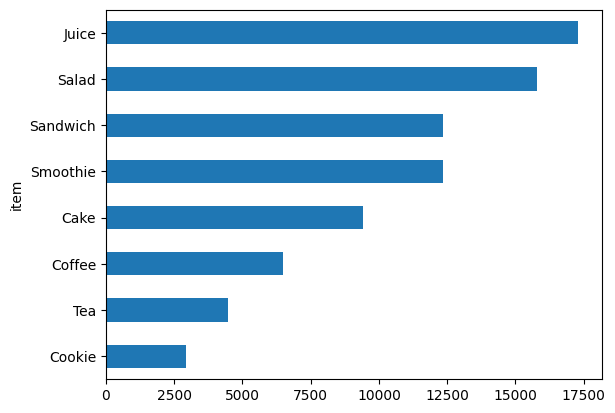

In [256]:
# Те саме у вигляді горизонтального барчарту
# .plot.barh() — horizontal bar chart, зручний коли назви категорій довгі
df.groupby('item')['total_spent'].sum().sort_values().plot.barh();

## 4.2 Порівняння виручки та кількості продажів по товарах

Два графіки поруч для порівняння:
- **лівий** — сумарна виручка (`total_spent`) по кожному товару
- **правий** — кількість транзакцій (`value_counts`) по кожному товару

Якщо товар продається часто але дає малу виручку — він дешевий. Якщо рідко але багато — дорогий. Порівняння двох графіків одразу показує цю різницю.

`plt.subplots(1, 2)` — створює фігуру з 1 рядком і 2 колонками графіків.  
`ax=ax` — передає конкретну вісь у `.plot()`, щоб графік намалювався саме там.

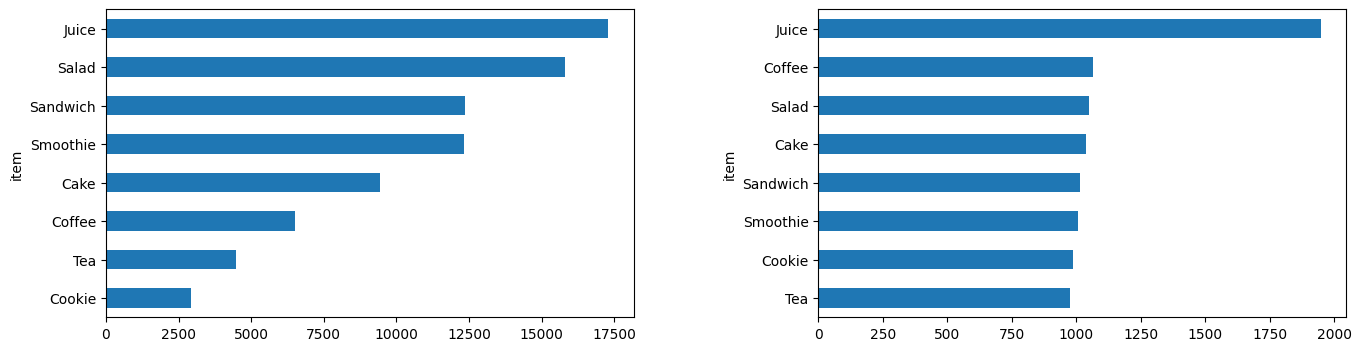

In [257]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("")
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# total_spent per item — сумарна виручка по товару
ax = axes[0]  # axes[0, 0]
df.groupby('item')['total_spent'].sum().sort_values().plot(kind='barh', ax=ax)

# count per item — кількість продажів по товару
ax = axes[1]  # axes[0, 1]
df['item'].value_counts().sort_values().plot(kind='barh', ax=ax)

plt.show()